<a href="https://colab.research.google.com/github/aavarela/SPBD_Labs/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Java Setup (needed for pyspark)
!apt-get install -y openjdk-17-jre 2>/dev/null > /dev/null

In [2]:
#@title Download 1% sample
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

In [3]:
#@title Dataset Schema
from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *

spark = SparkSession.builder.master('local[*]').appName('taxis').getOrCreate()

try :
    data = spark.read.csv('taxi_rides_1pc.csv.gz', sep =',', header=True, inferSchema=True)

    data.printSchema()

except Exception as err:
    print(err)

root
 |-- medallion: string (nullable = true)
 |-- hack_license: string (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- trip_time_in_secs: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- surcharge: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)



##**Question to AI agent**
To clean the data we remove null and invalid entries. What else should we look for?

##**AI response**
To further clean the data, you should also consider removing trips where trip_profit or trip_distance are zero or negative, as these are likely erroneous entries and could skew the analysis.

In [4]:
#@title Clean the data
from pyspark.sql.functions import col, isnan, when, floor

# Filter out rows with null or invalid coordinate values
cleaned_data = data.filter(
    col("pickup_latitude").isNotNull() & ~isnan(col("pickup_latitude")) &
    col("pickup_longitude").isNotNull() & ~isnan(col("pickup_longitude")) &
    col("dropoff_latitude").isNotNull() & ~isnan(col("dropoff_latitude")) &
    col("dropoff_longitude").isNotNull() & ~isnan(col("dropoff_longitude"))
)

# Longitude and latitude from the upper left corner of the grid
MIN_LON = -74.916578
MAX_LAT = 41.47718278

# Longitude and latitude that correspond to a shift in 500 meters
LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

# Convert coordinates (latitude,longitude) to grids (x,y)
data_with_grid_coords = cleaned_data \
    .withColumn("pickup_grid_x", floor((MAX_LAT - col("pickup_latitude")) / LAT_DELTA)) \
    .withColumn("pickup_grid_y", floor((col("pickup_longitude") - MIN_LON) / LON_DELTA)) \
    .withColumn("dropoff_grid_x", floor((MAX_LAT - col("dropoff_latitude")) / LAT_DELTA)) \
    .withColumn("dropoff_grid_y", floor((col("dropoff_longitude") - MIN_LON) / LON_DELTA))

# Filter the DataFrame to include only trips within the 300x300 grid for both pickup and dropoff,
# and also filter out trips with zero or negative distance.
filtered_data = data_with_grid_coords.filter(
    (col("pickup_grid_x") > 0) & (col("pickup_grid_x") < 300) &
    (col("pickup_grid_y") > 0) & (col("pickup_grid_y") < 300) &
    (col("dropoff_grid_x") > 0) & (col("dropoff_grid_x") < 300) &
    (col("dropoff_grid_y") > 0) & (col("dropoff_grid_y") < 300) &
    (col("trip_distance") > 0) # Filter out trips with zero or negative distance
)

In [5]:
#@title Calculate trip_profit
final_data = filtered_data.withColumn("trip_profit", col("fare_amount") + col("tip_amount"))

In [6]:
#@title Display data reduction results and final data schema
print("Original DataFrame count:", data.count())
print("Cleaned DataFrame count (after removing null coords):", cleaned_data.count())
print("DataFrame with grid coordinates, filtered and profit count:", final_data.count())
final_data.printSchema()

Original DataFrame count: 1735010
Cleaned DataFrame count (after removing null coords): 1734973
DataFrame with grid coordinates, filtered and profit count: 1691820
root
 |-- medallion: string (nullable = true)
 |-- hack_license: string (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- trip_time_in_secs: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- surcharge: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_grid_x: long (nullable = true)
 |-- pickup_grid_y

#Q1: Which areas are more profitable?

##**Question to AI agent**
This code calculates the average profit and number of empty taxis per area. The profit per area is computed by calculating the average profit (fare+tip) for trips that started in the area and ended within the last 15 minutes. The number of empty taxis in an area is the sum of taxis that had a drop-off location in that area less than 30 minutes ago and had no following pickup yet. Do you have any suggestions?

##**AI response**
I've reviewed the code against your definitions. The calculation for 'average profit per area' is already correctly implemented to consider trips that ended within the last 15 minutes. However, the logic for determining the 'number of empty taxis' needs a slight adjustment to precisely match your definition. Currently, it flags a taxi as empty if its next pickup is more than 30 minutes later. To accurately capture "taxis that had a drop-off location in that area less than 30 minutes ago and had no following pickup yet," update the is_empty_taxi condition. It should count taxis that either have no subsequent pickup (last trip) or whose next pickup occurs within 30 minutes of their drop-off, reflecting recent availability. This modification will align the empty taxi count with your specified criteria.

In [7]:
#@title Calculate average profit and number of empty taxis per area
from pyspark.sql.functions import avg, col, unix_timestamp
from pyspark.sql.functions import lead, count, datediff, when, lit
from pyspark.sql.window import Window

# Calculate trip duration in minutes
# (unix_timestamp returns seconds, so divide by 60 for minutes)
filtered_for_profit_calculation = final_data.withColumn(
    "trip_duration_minutes",
    (unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))) / 60
)

# Filter to include only trips where the duration is 15 minutes or less
filtered_for_profit_calculation = filtered_for_profit_calculation.filter(col("trip_duration_minutes") <= 15)

# Group by pickup grid coordinates and calculate the average trip_profit for the filtered data
avg_profit_per_pickup_area = filtered_for_profit_calculation.groupBy("pickup_grid_x", "pickup_grid_y").agg(avg("trip_profit").alias("avg_trip_profit"))

# Display the schema and first few rows of the resulting DataFrame
print("Schema of avg_profit_per_pickup_area:")
avg_profit_per_pickup_area.printSchema()
print("\nFirst 10 rows of avg_profit_per_pickup_area:")
avg_profit_per_pickup_area.show(10)

# Define the window specification: partition by medallion, order by pickup_datetime
window_spec = Window.partitionBy("medallion").orderBy("pickup_datetime")

# Add next_pickup_datetime
data_with_next_pickup = final_data.withColumn(
    "next_pickup_datetime",
    lead(col("pickup_datetime"), 1).over(window_spec)
)

# Calculate time_to_next_pickup_minutes convereting timestamps to Unix
# timestamps (seconds) for accurate difference calculation
data_with_next_pickup = data_with_next_pickup.withColumn(
    "time_to_next_pickup_minutes",
    (unix_timestamp(col("next_pickup_datetime")) - unix_timestamp(col("dropoff_datetime"))) / 60
)

# Create is_empty_taxi status
# Flag data for which the next_pickup_datetime is null (last trip) or the time_to_next_pickup_minutes is > 30
final_data_with_empty_status = data_with_next_pickup.withColumn(
    "is_empty_taxi",
    when(
        (col("next_pickup_datetime").isNull()) | (col("time_to_next_pickup_minutes") > 30),
        True
    ).otherwise(False)
)

# Display schema and first few rows
print("Schema of DataFrame with empty taxi status:")
final_data_with_empty_status.printSchema()
print("\nFirst 10 rows of DataFrame with empty taxi status (showing relevant columns):")
final_data_with_empty_status.select(
    "medallion", "pickup_datetime", "dropoff_datetime",
    "next_pickup_datetime", "time_to_next_pickup_minutes",
    "is_empty_taxi"
).orderBy("medallion", "pickup_datetime").show(10, truncate=False)

# Calculate the count of empty taxi instances per dropoff grid area
empty_taxi_count_per_dropoff_area = final_data_with_empty_status.filter(
    col("is_empty_taxi") == True
).groupBy("dropoff_grid_x", "dropoff_grid_y") \
 .agg(count("medallion").alias("empty_taxi_count"))

# Display the schema and first few rows of the resulting DataFrame
print("Schema of empty_taxi_count_per_dropoff_area:")
empty_taxi_count_per_dropoff_area.printSchema()
print("\nFirst 10 rows of empty_taxi_count_per_dropoff_area:")
empty_taxi_count_per_dropoff_area.show(10)

Schema of avg_profit_per_pickup_area:
root
 |-- pickup_grid_x: long (nullable = true)
 |-- pickup_grid_y: long (nullable = true)
 |-- avg_trip_profit: double (nullable = true)


First 10 rows of avg_profit_per_pickup_area:
+-------------+-------------+------------------+
|pickup_grid_x|pickup_grid_y|   avg_trip_profit|
+-------------+-------------+------------------+
|          179|          155| 9.748099688473522|
|          178|          160|10.549487179487178|
|          161|          150|            8.4375|
|          153|          172|               3.0|
|          166|          196|             12.25|
|          157|          149|               6.0|
|          161|          193|              12.0|
|          171|          170|             7.425|
|          155|          151|13.666666666666666|
|          176|          251|             184.0|
+-------------+-------------+------------------+
only showing top 10 rows

Schema of DataFrame with empty taxi status:
root
 |-- medallion: 

In [8]:
#@title 3. Calculate area profitability
from pyspark.sql.functions import col, when, desc

# Join the two DataFrames on matching grid coordinates
area_profitability = avg_profit_per_pickup_area.join(
    empty_taxi_count_per_dropoff_area,
    (avg_profit_per_pickup_area["pickup_grid_x"] == empty_taxi_count_per_dropoff_area["dropoff_grid_x"]) &
    (avg_profit_per_pickup_area["pickup_grid_y"] == empty_taxi_count_per_dropoff_area["dropoff_grid_y"]),
    "inner" # Use inner join to only consider areas present in both
)

# Calculate the profitability ratio, handling division by zero
area_profitability = area_profitability.withColumn(
    "profitability",
    when(col("empty_taxi_count") > 0,
         col("avg_trip_profit") / col("empty_taxi_count"))
    .otherwise(0.0) # Assign 0.0 or another suitable value if empty_taxi_count is zero
)

# Order the output by profitability ratio in descending order
area_profitability = area_profitability.orderBy(desc("profitability"))

# Display the schema and first few rows of the resulting DataFrame
print("Schema of area_profitability:")
area_profitability.printSchema()
print("\nFirst 10 rows of area_profitability:")
area_profitability.show(10)

Schema of area_profitability:
root
 |-- pickup_grid_x: long (nullable = true)
 |-- pickup_grid_y: long (nullable = true)
 |-- avg_trip_profit: double (nullable = true)
 |-- dropoff_grid_x: long (nullable = true)
 |-- dropoff_grid_y: long (nullable = true)
 |-- empty_taxi_count: long (nullable = false)
 |-- profitability: double (nullable = true)


First 10 rows of area_profitability:
+-------------+-------------+---------------+--------------+--------------+----------------+-------------+
|pickup_grid_x|pickup_grid_y|avg_trip_profit|dropoff_grid_x|dropoff_grid_y|empty_taxi_count|profitability|
+-------------+-------------+---------------+--------------+--------------+----------------+-------------+
|          235|           65|          260.0|           235|            65|               1|        260.0|
|           99|          215|          222.0|            99|           215|               1|        222.0|
|          176|          251|          184.0|           176|           251|   

##**Question to AI agent**
Is the heat map a suitable visualization to gain insight into the area profitability data?

##**AI response**
Yes, a heat map is a very suitable visualization for gaining insight into area profitability data. It effectively displays the spatial distribution of profitability across the grid, allowing you to quickly identify areas (hotspots) with higher profitability and understand their geographical spread. The color gradient makes it easy to discern variations and patterns at a glance. It's an excellent way to visualize which specific pickup locations are most lucrative given the number of empty taxis.

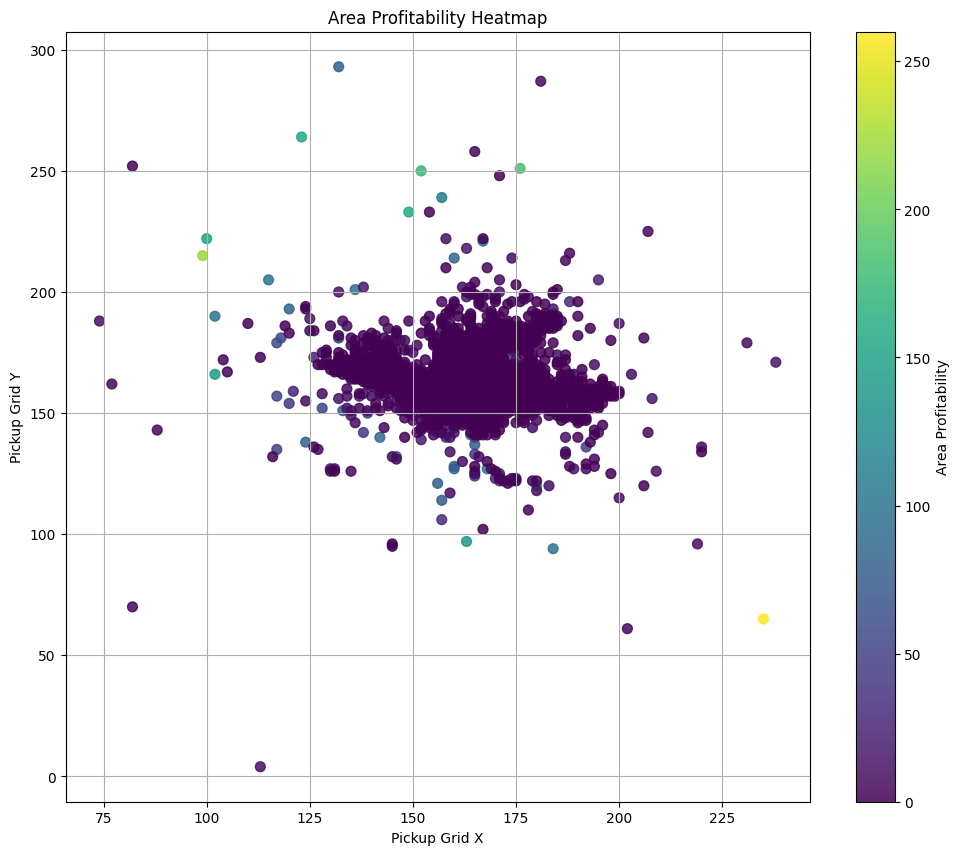

In [9]:
#@title Show a heat map of the profitability data to highlight the most profitable areas.
import matplotlib.pyplot as plt

# Convert the Spark DataFrame to a Pandas DataFrame for visualization
profitability_df_pd = area_profitability.toPandas()

# Create a scatter plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    profitability_df_pd['pickup_grid_x'],
    profitability_df_pd['pickup_grid_y'],
    c=profitability_df_pd['profitability'], # Color by profitability
    cmap='viridis', # Colormap
    s=50, # Size of the points
    alpha=0.85 # Transparency of the points
)

plt.colorbar(scatter, label='Area Profitability')
plt.xlabel('Pickup Grid X')
plt.ylabel('Pickup Grid Y')
plt.title('Area Profitability Heatmap')
plt.grid(True)
plt.show()

##**Question to AI agent**
The heat map shows a large number of low profit areas and a small number of high profit areas, indicating a skewed distribution with some outliers. What do you suggest to gain more insight into the distribution?

##**AI response**
To gain more insight into the skewed distribution and identify the characteristics of the high-profit outliers, I suggest we visualize the distribution more directly using histograms and box plots, and also calculate some key summary statistics. This will allow us to quantify the skewness and the extent of these outliers.

In [ ]:
#@title Show histogram of the profitability data
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'profitability' column to a Pandas Series for plotting
profitability_pd = area_profitability.select('profitability').toPandas()['profitability']

# Show histogram
plt.figure(figsize=(10, 6))
sns.histplot(profitability_pd, bins=50)
plt.title('Distribution of Area Profitability')
plt.xlabel('Profitability')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
#@title Show boxplot of the profitability data
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'profitability' column to a Pandas Series for plotting
profitability_pd = area_profitability.select('profitability').toPandas()['profitability']

# Show boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=profitability_pd)
plt.title('Box Plot of Area Profitability')
plt.xlabel('Profitability')
plt.grid(axis='x', alpha=0.75)
plt.show()

##**Question to AI agent**
Should we calculate some key summary statistics of the profitability data?

##**AI response**
Yes, this will give us a comprehensive overview of the distribution. To calculate key summary statistics for the profitability data, use PySpark's agg function with min, max, mean, stddev, and count on the area_profitability DataFrame.

In [18]:
#@title Show some key summary statistics of the profitability data
from pyspark.sql.functions import min, max, mean, stddev, count

# Calculate key summary statistics
summary_stats_agg = area_profitability.agg(
    min('profitability').alias('min_profitability'),
    max('profitability').alias('max_profitability'),
    mean('profitability').alias('mean_profitability'),
    stddev('profitability').alias('stddev_profitability'),
    count('profitability').alias('count_profitability')
)
summary_stats_agg.show()

+-----------------+-----------------+------------------+--------------------+-------------------+
|min_profitability|max_profitability|mean_profitability|stddev_profitability|count_profitability|
+-----------------+-----------------+------------------+--------------------+-------------------+
|              0.0|            260.0| 4.285668615470877|  17.321423436056918|               1719|
+-----------------+-----------------+------------------+--------------------+-------------------+



#Q2: How do the profitability varies with the trip distance?

In [ ]:
#@title Visualize the trip profits as a funtion of the trips distance
from pyspark.sql.functions import avg, col, when
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define distance bins for trip_distance
final_data_with_bins = final_data.withColumn(
    "distance_bin",
    when((col("trip_distance") >= 0) & (col("trip_distance") < 1), "0-1 miles")
    .when((col("trip_distance") >= 1) & (col("trip_distance") < 2), "1-2 miles")
    .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2-5 miles")
    .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "5-10 miles")
    .otherwise(">10 miles")
)

print("Schema of final_data_with_bins:")
final_data_with_bins.printSchema()
print("First 10 rows of final_data_with_bins (showing distance_bin):")
final_data_with_bins.select("trip_distance", "distance_bin").show(10)

# Group by distance_bin and calculate the average trip_profit
avg_profit_by_distance = final_data_with_bins.groupBy("distance_bin").agg(avg("trip_profit").alias("average_trip_profit"))

# Define the order for distance bins for better visualization
distance_bin_order = ["0-1 miles", "1-2 miles", "2-5 miles", "5-10 miles", ">10 miles"]

# Convert to Pandas DataFrame and reorder the bins
avg_profit_by_distance_pd = avg_profit_by_distance.toPandas()
avg_profit_by_distance_pd['distance_bin'] = pd.Categorical(avg_profit_by_distance_pd['distance_bin'], categories=distance_bin_order, ordered=True)
avg_profit_by_distance_pd = avg_profit_by_distance_pd.sort_values('distance_bin')

print("Average profit by distance bin (Pandas DataFrame):")
print(avg_profit_by_distance_pd)

# Create a bar plot to visualize average trip profit by distance bin
plt.figure(figsize=(10, 6))
sns.barplot(x='distance_bin',
            y='average_trip_profit',
            data=avg_profit_by_distance_pd,
            palette='viridis',
            hue='distance_bin',
            legend=False)

plt.title('Average Trip Profit by Distance Bin')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Average Trip Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Q3: How do the profitability varies with the time of day?

In [ ]:
#@title Visualize the trip profits as a function of the time of day
from pyspark.sql.functions import avg, col, hour, when, stddev
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the hour from 'pickup_datetime'
final_data_with_hour = final_data.withColumn("pickup_hour", hour(col("pickup_datetime")))

# Create time_of_day_bin based on pickup_hour
final_data_with_time_bins = final_data_with_hour.withColumn(
    "time_of_day_bin",
    when((col("pickup_hour") >= 6) & (col("pickup_hour") <= 11), "Morning (6-11)")
    .when((col("pickup_hour") >= 12) & (col("pickup_hour") <= 17), "Afternoon (12-17)")
    .when((col("pickup_hour") >= 18) & (col("pickup_hour") <= 23), "Evening (18-23)")
    .otherwise("Night (0-5)")
)

print("Schema of final_data_with_time_bins:")
final_data_with_time_bins.printSchema()
print("First 10 rows of final_data_with_time_bins (showing pickup_datetime, pickup_hour, time_of_day_bin):")
final_data_with_time_bins.select("pickup_datetime", "pickup_hour", "time_of_day_bin").show(10)

# Group by time_of_day_bin and calculate the average and standard deviation of trip_profit
avg_profit_by_time_of_day = final_data_with_time_bins.groupBy("time_of_day_bin").agg(
    avg("trip_profit").alias("average_trip_profit"),
    stddev("trip_profit").alias("stddev_trip_profit")
)

# Define the order for time of day bins for better visualization
time_of_day_bin_order = ["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"]

# Convert to Pandas DataFrame and reorder the bins
avg_profit_by_time_of_day_pd = avg_profit_by_time_of_day.toPandas()
avg_profit_by_time_of_day_pd['time_of_day_bin'] = pd.Categorical(avg_profit_by_time_of_day_pd['time_of_day_bin'], categories=time_of_day_bin_order, ordered=True)
avg_profit_by_time_of_day_pd = avg_profit_by_time_of_day_pd.sort_values('time_of_day_bin')

print("Average and standard deviation of profit by time of day bin (Pandas DataFrame):")
print(avg_profit_by_time_of_day_pd)

# Create a bar plot to visualize average trip profit by time of day bin
plt.figure(figsize=(10, 6))
sns.barplot(x='time_of_day_bin',
            y='average_trip_profit',
            data=avg_profit_by_time_of_day_pd,
            palette='viridis',
            hue='time_of_day_bin',
            legend=False)

plt.title('Average Trip Profit by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Trip Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**Question to AI agent**
The profitability data shows little variation with the time of day of the trips. How can we add the standard deviation to thye plot to infer about the data distribution in each interval?

##**AI response**
Include errorbar='sd' in the sns.barplot function.

##**Question to AI agent**
The error bars are not displayed.

##**AI response**
I'll modify the code to use matplotlib.pyplot directly for plotting both the bars and the error bars. This gives finer control and should make the error bars visible.

In [ ]:
#@title Visualize the trip profits as a function of the time of day
from pyspark.sql.functions import avg, col, hour, when, stddev, count # Added count
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract the hour from 'pickup_datetime'
final_data_with_hour = final_data.withColumn("pickup_hour", hour(col("pickup_datetime")))

# Create time_of_day_bin based on pickup_hour
final_data_with_time_bins = final_data_with_hour.withColumn(
    "time_of_day_bin",
    when((col("pickup_hour") >= 6) & (col("pickup_hour") <= 11), "Morning (6-11)")
    .when((col("pickup_hour") >= 12) & (col("pickup_hour") <= 17), "Afternoon (12-17)")
    .when((col("pickup_hour") >= 18) & (col("pickup_hour") <= 23), "Evening (18-23)")
    .otherwise("Night (0-5)")
)

print("Schema of final_data_with_time_bins:")
final_data_with_time_bins.printSchema()
print("First 10 rows of final_data_with_time_bins (showing pickup_datetime, pickup_hour, time_of_day_bin):")
final_data_with_time_bins.select("pickup_datetime", "pickup_hour", "time_of_day_bin").show(10)

# Group by time_of_day_bin and calculate the average, standard deviation, and count of trip_profit
avg_profit_by_time_of_day = final_data_with_time_bins.groupBy("time_of_day_bin").agg(
    avg("trip_profit").alias("average_trip_profit"),
    stddev("trip_profit").alias("stddev_trip_profit"),
    count("trip_profit").alias("count_trip_profit") # Added count
)

# Define the order for time of day bins for better visualization
time_of_day_bin_order = ["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"]

# Convert to Pandas DataFrame and reorder the bins
avg_profit_by_time_of_day_pd = avg_profit_by_time_of_day.toPandas()
avg_profit_by_time_of_day_pd['time_of_day_bin'] = pd.Categorical(avg_profit_by_time_of_day_pd['time_of_day_bin'], categories=time_of_day_bin_order, ordered=True)
avg_profit_by_time_of_day_pd = avg_profit_by_time_of_day_pd.sort_values('time_of_day_bin')

print("Average and standard deviation of profit by time of day bin (Pandas DataFrame):")
print(avg_profit_by_time_of_day_pd)

# Create a bar plot and error bars to visualize average trip profit by time of day bin
plt.figure(figsize=(10, 6))

# Get positions for the bars
x_pos = np.arange(len(avg_profit_by_time_of_day_pd))

# Plot the bars
plt.bar(x_pos,
        avg_profit_by_time_of_day_pd['average_trip_profit'],
        color='skyblue',
        width=0.6)

# Add error bars using the standard deviation
plt.errorbar(x_pos,
             avg_profit_by_time_of_day_pd['average_trip_profit'],
             yerr=avg_profit_by_time_of_day_pd['stddev_trip_profit'], # Using stddev for error bars
             fmt='o',          # Format of the data points (dots)
             color='black',    # Color of the error bars
             capsize=5,        # Length of the error bar caps
             elinewidth=2)     # Thickness of the error bar lines

plt.title('Average Trip Profit by Time of Day (with Standard Deviation)')
plt.xlabel('Time of Day')
plt.ylabel('Average Trip Profit')
plt.xticks(x_pos, avg_profit_by_time_of_day_pd['time_of_day_bin'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()